# Physics-Informed Time-Integrated Operator (PITI-FNO)

*A label-free transient operator that learns the **time derivative** of the temperature field rather than a fixed-$\Delta t$ step, so the time step and the integrator are chosen only at inference.*

---

## 1. Motivation

The weighted-residual operator of the previous chapter is label-free, but it bakes a single backward-Euler step of size $\Delta t=0.02$ into its training residual. The trained weights are tied to that $\Delta t$ and must be retrained for any other. PITI removes this coupling. A single-output FNO maps the current state to its tangent,
$$\mathcal G_\theta: T^n \longmapsto \tilde T^n_t ,$$
and is trained on the **semi-discrete** FEM residual $M\,\dot T + K(T)\,T = 0$, where $\Delta t$ never appears. Any classical integrator (here **explicit Euler** and **RK4**) can then step the learned tangent at any $\Delta t$.

## 2. Training objective

One loss term, evaluated directly on $T^n$, in the same stop-gradient weighted-residual form as the previous chapter:
$$\mathcal L_{PDE} = \frac{\big\langle \tilde T^n_t,\ \text{stop\_grad}\big(M\,\tilde T^n_t + K(T^n)T^n\big) \big\rangle_{\text{free nodes}}}{\big\|K(T^n)T^n\big\|^2_{\text{free nodes}} + \epsilon}$$
The Dirichlet boundary is hard-enforced by a $\sin(\pi x)$ output mask ($\tilde T^n_{t,0}=\tilde T^n_{t,-1}=0$ exactly, for any weights), so no boundary loss term is needed.

## 3. A like-for-like setup

Everything except the training signal matches the weighted-residual chapter. Both use the same $T_0$-only training pool (800 states, all at $t=0$), the same validation and held-out test samples, the same FNO backbone (`WIDTH=64`, `MODES=4`, $\sin(\pi x)$ mask), the same epoch budget (`MAX_EPOCHS=20000`, early-stopped) and the same FEM ground truth. The reference is fully-implicit backward Euler, solved by Newton–Raphson:
$$M\,\frac{T^{n+1}-T^n}{\Delta t} + K(T^{n+1})\,T^{n+1} = 0$$


**Shared ground truth.** Every transient chapter in this book reads its initial fields, materials and reference trajectories from one module, `fem_ground_truth.py`. A fixed pool of 1000 $(T_0,\alpha)$ fields (a Fourier-series / Gaussian-random-process / constant mixture, after Yamazaki et al. 2025, Sect. 3.3) is solved **once** with fully-implicit backward-Euler FEM (Newton–Raphson, exact Jacobian) on a fine mesh ($N=256$, $\Delta t=0.001$, $t\in[0,0.4]$). Each chapter then derives its own $(N,\Delta t)$ from that one solve by spatial interpolation and exact time sub-sampling, without re-solving. So every model is graded against the same converged answer, and not against a coarse solve that carries its own discretization error. The 1000 samples are split 800 / 100 / 100 (train / validation for early stopping / held-out test) identically in every chapter. Out-of-distribution scenarios come from the same module (50 unseen shapes solved once at $N=512$). Full details: [The Benchmark Problem](benchmark_problem.ipynb).

In [1]:
# ============================================================
# Config. dt appears here ONLY to shape which dt's are swept at
# inference (Section 7) -- it never enters the training loss.
#
# FEM ground truth (assembly, Newton-Raphson solver) is imported from
# fem_ground_truth.py.
# ============================================================
import jax, jax.numpy as jnp
import numpy as np, matplotlib.pyplot as plt
import optax, time
from functools import partial

# fem_ground_truth.py lives next to this notebook; make sure it is importable
# regardless of the kernel's working directory (VS Code / Jupyter do not always
# default to the notebook's own folder).
import sys, os
_FEM_DIR = os.path.abspath("")   # fem_ground_truth.py sits next to this notebook
if _FEM_DIR not in sys.path:
    sys.path.insert(0, _FEM_DIR)
from fem_ground_truth import (
    DEFAULT_RHO_CP, DEFAULT_NEWTON_ITERS,
    assemble_LM, solve_transient_fem_step, fem_rollout, batch_fem_rollout,
)

N_NODES = 64; N_GRID = N_NODES - 1; WIDTH = 64
MODES = 4          # the training T0 distribution carries 99.5% of its perturbation energy
                   # in modes 1-3 and only 0.5% in modes 4-7 -- spectral weights above mode 3
                   # are barely constrained by the loss.
N_SAMPLES = 1000; TRAIN_SAMPLES = 800
VAL_SAMPLES = 100                                   # held out from training, used for early stopping
ROLLOUT_TEST_START = TRAIN_SAMPLES + VAL_SAMPLES    # remaining 100 samples: untouched until Section 7/8 rollout
RHO_CP = DEFAULT_RHO_CP
NEWTON_ITERS = DEFAULT_NEWTON_ITERS  # Newton-Raphson iterations for the fully-implicit FEM reference solver (fem_ground_truth.py)
GRID = jnp.linspace(0, 1, N_NODES)
FREE = jnp.arange(1, N_NODES - 1)

# --- dt / horizon: everything below is anchored to fem_ground_truth.py's own
# fine reference dt, and every rollout in the notebook reaches the same final
# physical time as the FEM ground truth it's compared against. ---
DT_REF = 0.0002     # fem_ground_truth.py's fine reference dt -- every dt used below (pool AND
                    # inference) is an exact integer multiple of this, so every rollout in this
                    # notebook lands exactly on the fem ground-truth fine time grid, never interpolated.
FINAL_TIME = 0.5    # universal horizon: FEM ground truth AND every inference-time integrator/dt
                    # below are rolled out to exactly this physical time, not to different horizons.

INFER_DT_GRID = [0.001, 0.01, 0.02, 0.1]            # inference-time step sizes -- decoupled from training
for _dt in INFER_DT_GRID:
    assert abs(round(_dt / DT_REF) - _dt / DT_REF) < 1e-9, \
        f"dt={_dt} is not an exact multiple of DT_REF={DT_REF} -- would not land on the fem time grid"
    assert abs(round(FINAL_TIME / _dt) - FINAL_TIME / _dt) < 1e-9, \
        f"FINAL_TIME={FINAL_TIME} is not an exact multiple of dt={_dt}"
HORIZON_STEPS_AT = {dt: round(FINAL_TIME / dt) for dt in INFER_DT_GRID}  # every dt reaches t=FINAL_TIME exactly

# Explicit integrators only.
INTEGRATORS = ["euler", "rk4"]
INTEG_LABELS = {"euler": "Explicit Euler", "rk4": "RK4"}
INTEG_COLORS = {"euler": "#0077BB", "rk4": "#EE7733"}
INTEG_MARKERS = {"euler": "o", "rk4": "^"}

print("config ready")


config ready


In [2]:
# ============================================================
# Physics: FEM assembly/solver/IC-sampler are imported from
# fem_ground_truth.py (single source of truth, shared with every other
# notebook in this project) -- see Cell 1's import. Used for two things
# only: building the training-state pool (Section 4) and generating the
# rollout comparison target (Section 7) -- the network never touches
# this solver directly.
#
# The PITI loss (Section 5) needs the raw mass/stiffness matrices M, K
# separately (no dt folded in), but fem_ground_truth.py only exposes the
# dt-combined LHS = M + dt*K (assemble_LM), since that's all its own
# implicit-Euler solver needs. assemble_mk below recovers M and K from
# two assemble_LM calls (dt=0 gives LHS=M; dt=1 gives LHS=M+K, so
# K = LHS(dt=1) - M) instead of reassembling them by hand, so this
# notebook still has exactly one implementation of the FEM math to stay
# consistent with.
# ============================================================
def assemble_mk(T, alpha_x):
    M, _ = assemble_LM(T, alpha_x, dt=0.0, rho_cp=RHO_CP)
    LHS1, _ = assemble_LM(T, alpha_x, dt=1.0, rho_cp=RHO_CP)
    K = LHS1 - M
    return M, K

print("physics ready (FEM assembly/solver from fem_ground_truth.py)")


physics ready (FEM assembly/solver from fem_ground_truth.py)


## 4. Training data: the $T_0$ state pool

The training pool consists of 1000 initial-condition states $T_i(x)$, each paired with its own conductivity field $\alpha(x)$, read from the precomputed reference FEM trajectory's own $t=0$ slice -- no rollout or additional FEM solving is needed to build this pool. No target values are stored alongside these states: the loss (Section 5) is a physics residual evaluated directly on $T$ and $\alpha$, so nothing needs to be precomputed here beyond the states themselves.

The 1000 $(T_i,\alpha)$ pairs are split 800 / 100 / 100: 800 for training, 100 held out for validation (early stopping), and the last 100 held back entirely (`ROLLOUT_TEST_START`) for Section 7's rollout evaluation -- so no trajectory snapshot from a test sample is ever seen during training or validation.


In [3]:
from fem_ground_truth import get_reference_trajectory, derive_dataset

_CKPT_DIR = os.path.join(_FEM_DIR, "checkpoints")
CKPT_DT_REF = 0.001    # checkpoints/fine_reference.npz's own dt -- the finest dt available without re-solving
CKPT_STEPS_REF = 400   # -> reference covers t in [0, 0.4]
reference_data = get_reference_trajectory(os.path.join(_CKPT_DIR, "fine_reference.npz"), os.path.join(_CKPT_DIR, "field_pool.npz"),
                                           dt_ref=CKPT_DT_REF, steps_ref=CKPT_STEPS_REF)

# ============================================================
# T0-ONLY TRAINING POOL
#
# The training pool is the initial state only: 1000 (T0, alpha) pairs, all
# at t = 0. No dt appears anywhere in this cell (T0 is the state at t = 0
# regardless of dt), and no FEM solving is needed here -- states are read
# directly from the reference trajectory's own t = 0 slice.
#
# Every rollout step past the first (Section 7) is therefore extrapolation
# for the trained operator.
# ============================================================
derived = derive_dataset(reference_data, n_nodes_target=N_NODES, dt_target=CKPT_DT_REF)

pool_states = jnp.asarray(derived["T0"])[:, None, :]        # (N_SAMPLES, 1, N_NODES)
pool_alphas = jnp.asarray(derived["alpha"])[:, None, :]     # (N_SAMPLES, 1, N_NODES)
print(f"[T0-only] pooled {pool_states.shape[0]} states (all at t = 0)")

train_states = pool_states[:TRAIN_SAMPLES].reshape(-1, N_NODES)
train_alphas = pool_alphas[:TRAIN_SAMPLES].reshape(-1, N_NODES)
val_states = pool_states[TRAIN_SAMPLES:ROLLOUT_TEST_START].reshape(-1, N_NODES)
val_alphas = pool_alphas[TRAIN_SAMPLES:ROLLOUT_TEST_START].reshape(-1, N_NODES)

state_mean, state_std = float(train_states.mean()), float(train_states.std()) + 1e-7
alpha_mean, alpha_std = float(train_alphas.mean()), float(train_alphas.std()) + 1e-7

print(f"train pool: {train_states.shape[0]} states | val pool: {val_states.shape[0]} states "
      f"| {N_SAMPLES - ROLLOUT_TEST_START} samples held out for rollout")


[T0-only] pooled 1000 states (all at t = 0)
train pool: 800 states | val pool: 100 states | 100 samples held out for rollout


## 5. Single-output FNO and weighted-residual loss

The network maps the current state directly to its tangent, with one read-out head:
$$\mathcal G_\theta: T^n \longmapsto \tilde T^n_t$$

**Boundary condition.** The output is multiplied by $\sin(\pi x)$, which is exactly zero at both boundary nodes: $\tilde T^n_{t,0}=\tilde T^n_{t,-1}=0$ for any weights. A fixed-in-time Dirichlet boundary has zero tangent, so this is exact -- no boundary loss term is needed.

**Governing residual.** After finite-element discretization, the PDE is the semi-discrete residual
$$M\,\dot T + K(T)\,T = 0$$
where $M$ is the mass matrix (from $\rho c_p$, constant, independent of $T$) and $K(T)$ is the stiffness matrix, nonlinear because the conductivity depends on temperature, $k(x,T)=\alpha(x)(0.5+T^2)$. The network predicts $\tilde T^n_t \approx \dot T$; training only ever checks how well this residual is satisfied at the given state.

**The loss, per-sample normalized:**
$$\mathcal L_{PDE} = \frac{\Big\langle \tilde T^n_t,\ \text{stop\_grad}\big(M\,\tilde T^n_t + K(T^n)\,T^n\big) \Big\rangle_{\text{free nodes}}}{\big\|K(T^n)\,T^n\big\|^2_{\text{free nodes}} + \epsilon}$$

Term by term:
- $\tilde T^n_t = \mathcal G_\theta(T^n)$ -- the network's own output, the only trainable quantity in the expression.
- $M\,\tilde T^n_t + K(T^n)\,T^n$ -- the PDE residual with the network's own tangent plugged into the mass term; zero if the tangent were exact.
- $\text{stop\_grad}(\cdot)$ -- the residual is frozen before being used as a multiplier, so gradients only flow through the standalone $\tilde T^n_t$ factor. This makes the loss a linear (weighted-residual / test-function) form rather than a squared-residual form: the gradient only ever pushes $\tilde T^n_t$ to align with $-(\text{residual})$, the direction that would reduce it on the next update, without differentiating through the residual's own nonlinear $T$-dependence.
- $\langle\cdot,\cdot\rangle_{\text{free nodes}}$ -- a plain dot product restricted to interior (non-Dirichlet) nodes; the boundary nodes are excluded since their tangent is already hard-constrained to zero.
- $K(T^n)T^n$ in the denominator -- the diffusion-flux scale of that particular state; dividing by its squared norm makes the loss scale-invariant per sample. Unnormalized, a handful of samples with sharp initial-condition discontinuities produce a residual (and gradient push) hundreds of times larger than an ordinary state, and dominate every gradient step while typical states are barely trained on -- training did not NaN, but every rollout diverged to inf/NaN regardless of integrator or $\Delta t$.
- $\epsilon = 10^{-8}$ -- a floor against division by ~0 for near-equilibrium states where $K(T)T\approx 0$.

**Structure of the training signal.** This is a semi-discrete, continuous-time residual on the tangent itself, with $\Delta t$ absent throughout -- time integration is applied only at inference (Section 6). The target the residual is graded against is derived analytically from $T^n$ and $\alpha$ at that same state (via $M$, $K$), not from a labeled next-state or a precomputed trajectory.

**The one open risk this leaves:** the numerator is $M\cdot(\tilde T^n_t - \dot T_{phys}(T^n))$ for the physics tangent $\dot T_{phys}(T^n) = M^{-1}(-K(T^n)T^n)$, passed through the tridiagonal mass matrix $M$ before being graded. $M$ mixes each node with its two neighbors (weights $\propto[1,2,1]$), so it nearly cancels alternating-sign, node-to-node error components that a direct comparison would catch. If the rollout is unstable in a high-frequency spatial-oscillation way rather than a smooth exponential drift, that blind spot is the first thing to suspect.

**Validation metric.** $\mathcal L_{PDE}$ is signed (not bounded below at zero) because of the stop-gradient trick, so it is not meaningful for early-stopping. `piti_losses` also returns the plain squared, non-negative version of the same relative residual, computed from the same ingredients but never differentiated:
$$\text{pde\_quality} = \frac{\big\|M\,\tilde T^n_t + K(T^n)\,T^n\big\|^2_{\text{free nodes}}}{\big\|K(T^n)\,T^n\big\|^2_{\text{free nodes}} + \epsilon} \ \ge\ 0$$
used only for early-stopping/monitoring.


In [4]:
# ============================================================
# Single-output FNO: one read-out head (T_dot only). The Dirichlet
# boundary is hard-enforced via the sin(pi x) multiplicative mask
# (the correct boundary tangent is exactly zero).
# ============================================================
def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]; xf = jnp.fft.rfft(x, axis=0)
    of = jnp.zeros_like(xf, dtype=jnp.complex64).at[:MODES].set(jnp.einsum('mi,mij->mj', xf[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(of, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_tdot(params, x_norm):
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i + 1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    T_dot = (jnp.dot(x, params[12]) + params[13]).squeeze()
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, x_norm.shape[0]))
    return T_dot * mask

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i + 1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i + 5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH),      # hidden proj
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])             # T_dot head
    return p

def normalize_input(T, alpha, grid):
    Tn = (T - state_mean) / state_std
    an = (alpha - alpha_mean) / alpha_std
    return jnp.stack([Tn, an, grid], axis=-1)

print("single-output FNO ready")

single-output FNO ready


In [5]:
# ============================================================
# The ONLY loss term: a weighted-residual (stop_gradient) form,
# per-sample normalized. See Section 5 markdown for the full
# derivation, why the normalization is load-bearing, and the one
# theoretical blind spot this design leaves open.
#
# piti_losses returns two numbers per sample:
#   - L_pde:        the signed weighted-residual quantity that
#                    actually drives the gradient (via total).
#   - pde_quality:  the plain squared version of the same relative
#                    residual (non-negative, bounded below at 0) --
#                    used only for early-stopping/monitoring, never
#                    differentiated.
# ============================================================
LAMBDA_PDE = 1.0
REL_EPS = 1e-8   # floor against division by ~0 for near-equilibrium snapshots

def piti_losses(params, T_curr, alpha):
    T_dot_pred = fno_tdot(params, normalize_input(T_curr, alpha, GRID))
    M, K = assemble_mk(T_curr, alpha)
    pde_res = (M @ T_dot_pred + K @ T_curr)[FREE]
    pde_scale = (K @ T_curr)[FREE]
    denom = jnp.sum(pde_scale ** 2) + REL_EPS
    L_pde = jnp.sum(T_dot_pred[FREE] * jax.lax.stop_gradient(pde_res)) / denom
    pde_quality = jnp.sum(pde_res ** 2) / denom
    total = LAMBDA_PDE * L_pde
    return total, (L_pde, pde_quality)

MAX_EPOCHS = 20000
CHECK_EVERY = 200
PATIENCE = 15
BATCH_SIZE = 32

def make_opt(max_epochs):
    sched = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=max_epochs, alpha=1e-2)
    return optax.adamw(learning_rate=sched, weight_decay=1e-4)

@jax.jit
def batch_loss(params, T_batch, A_batch):
    total, parts = jax.vmap(piti_losses, (None, 0, 0))(params, T_batch, A_batch)
    return jnp.mean(total), tuple(jnp.mean(p) for p in parts)

@jax.jit
def val_metric(params, T_batch, A_batch):
    # pde_quality (index 1) -- non-negative, bounded-below relative
    # residual, used only for "best_val" bookkeeping. L_pde itself is
    # signed and unbounded, so it isn't meaningful for that purpose.
    _, parts = batch_loss(params, T_batch, A_batch)
    return parts[1]

def train_piti(seed=101):
    params = init_params(jax.random.PRNGKey(seed))
    opt = make_opt(MAX_EPOCHS); opt_state = opt.init(params)

    @jax.jit
    def step(p, opt_s, T_b, A_b):
        (loss, parts), g = jax.value_and_grad(lambda pp: batch_loss(pp, T_b, A_b), has_aux=True)(p)
        u, opt_s = opt.update(g, opt_s, p)
        return optax.apply_updates(p, u), opt_s, loss, parts

    best_val, best_params, best_epoch, stall = jnp.inf, params, 0, 0
    for i in range(MAX_EPOCHS):
        idx = jax.random.randint(jax.random.PRNGKey(seed * 1_000_003 + i), (BATCH_SIZE,), 0, train_states.shape[0])
        params, opt_state, loss, parts = step(params, opt_state, train_states[idx], train_alphas[idx])
        if i % CHECK_EVERY == 0:
            v = float(val_metric(params, val_states, val_alphas))
            improved = v < best_val
            if i % 2000 == 0:
                l_pde, quality = (float(x) for x in parts)
                print(f"  epoch {i:5d} | train L_pde[weighted-res] {l_pde:.2e} | pde_quality {quality:.2e} "
                      f"| val pde_quality {v:.3e}" + ("  * best" if improved else ""))
            if improved:
                best_val, best_params, best_epoch, stall = v, params, i, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    print(f"  early-stopped at epoch {i} (best val {best_val:.3e} @ epoch {best_epoch})")
                    break
    else:
        print(f"  hit max_epochs={MAX_EPOCHS} (best val {best_val:.3e} @ epoch {best_epoch})")
    return best_params

print("training setup ready -- single weighted-residual loss")

training setup ready -- single weighted-residual loss


In [6]:
t0 = time.perf_counter()
piti_params = train_piti()
jax.block_until_ready(piti_params)   # JAX is async -- without this we would time dispatch, not training
piti_train_time = time.perf_counter() - t0
print(f"training wall-clock: {piti_train_time:.1f}s")

# Saved for the comparison chapter (transient_comparison.ipynb), which re-grades all
# three transient operators side by side without retraining any of them.
np.savez(os.path.join(_CKPT_DIR, "params_piti.npz"), *[np.asarray(p) for p in piti_params])
print("saved checkpoints/params_piti.npz")

  epoch     0 | train L_pde[weighted-res] -3.94e-03 | pde_quality 9.98e-01 | val pde_quality 9.907e-01  * best


  epoch  2000 | train L_pde[weighted-res] 2.31e-01 | pde_quality 2.18e-01 | val pde_quality 2.475e-01  * best


  epoch  4000 | train L_pde[weighted-res] 3.71e-01 | pde_quality 1.64e-01 | val pde_quality 2.062e-01


  epoch  6000 | train L_pde[weighted-res] 6.11e-02 | pde_quality 1.40e-01 | val pde_quality 1.852e-01


  epoch  8000 | train L_pde[weighted-res] -9.01e-02 | pde_quality 1.44e-01 | val pde_quality 1.426e-01


  epoch 10000 | train L_pde[weighted-res] 8.32e-02 | pde_quality 8.96e-02 | val pde_quality 1.323e-01


  epoch 12000 | train L_pde[weighted-res] 1.13e-01 | pde_quality 9.45e-02 | val pde_quality 1.166e-01  * best


  epoch 14000 | train L_pde[weighted-res] -3.47e-01 | pde_quality 9.40e-02 | val pde_quality 1.204e-01


  early-stopped at epoch 15000 (best val 1.166e-01 @ epoch 12000)
training wall-clock: 131.6s
saved checkpoints/params_piti.npz


## 6. Inference-time integrators

The trained operator only ever produces $\tilde T_t = \mathcal G_\theta(T)$; everything below is classical time-stepping applied to that tangent, fully decoupled from training:

**Explicit Euler:** $T^{n+1}=T^n+\Delta t\,\tilde T^n_t$

**RK4:** $k_1=\mathcal G_\theta(T^n),\ k_2=\mathcal G_\theta(T^n+\tfrac{\Delta t}{2}k_1),\ k_3=\mathcal G_\theta(T^n+\tfrac{\Delta t}{2}k_2),\ k_4=\mathcal G_\theta(T^n+\Delta t\,k_3)$, $T^{n+1}=T^n+\tfrac{\Delta t}{6}(k_1+2k_2+2k_3+k_4)$

Both integrators share the same trained operator -- they differ only in how many times per step they call it, and in how much of the physics' stiffness spectrum they can tolerate before going unstable (see Section 8).


In [7]:
# ============================================================
# Inference-time integrators, both sharing the SAME trained operator.
# dt is a free argument here -- never fixed at training. Both are
# single-step schemes, so the scan's carry is just the state.
# ============================================================
def fno_tdot_only(params, T, alpha, grid):
    return fno_tdot(params, normalize_input(T, alpha, grid))

def step_euler(params, T_curr, alpha, grid, dt):
    return T_curr + dt * fno_tdot_only(params, T_curr, alpha, grid)

def step_rk4(params, T_curr, alpha, grid, dt):
    k1 = fno_tdot_only(params, T_curr, alpha, grid)
    k2 = fno_tdot_only(params, T_curr + 0.5 * dt * k1, alpha, grid)
    k3 = fno_tdot_only(params, T_curr + 0.5 * dt * k2, alpha, grid)
    k4 = fno_tdot_only(params, T_curr + dt * k3, alpha, grid)
    return T_curr + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

STEP_FNS = {"euler": step_euler, "rk4": step_rk4}

def make_rollout(step_fn):
    @partial(jax.jit, static_argnums=(4,))
    def rollout(params, T0, alpha, dt, n_steps):
        def body(T_curr, _):
            T_next = step_fn(params, T_curr, alpha, GRID, dt)
            return T_next, T_next
        _, traj = jax.lax.scan(body, T0, None, length=n_steps)
        return jnp.concatenate([T0[None, :], traj], axis=0)
    return rollout

def make_batch_rollout(step_fn):
    single = make_rollout(step_fn)
    def batch_rollout(params, T0b, ab, dt, n_steps):
        return jax.vmap(single, (None, 0, 0, None, None))(params, T0b, ab, dt, n_steps)
    return batch_rollout

print("inference integrators ready:", INTEGRATORS)


inference integrators ready: ['euler', 'rk4']


## 7. Test-set rollout: decoupling the time step

Rolls out the single trained operator with both integrators (explicit Euler, RK4), graded against the shared FEM reference (`fem_ground_truth.py`: the $N=256$, $\Delta t=0.001$ fully-implicit Newton–Raphson solve, sub-sampled to each inference $\Delta t$ and interpolated to $N=64$). The cached reference ends at $t=0.4$, so the last $0.1$ is continued with a fresh fully-implicit FEM solve that starts from the cached final state with the same material. Test ICs/$\alpha$ come from the 100 held-out samples (`ROLLOUT_TEST_START:`), never used in training or validation.

Error is mean absolute error, averaged over held-out samples $s$ and spatial nodes $j$, at each rollout step $n$:
$$\text{MAE}(n) = \frac{1}{N_{\text{test}}\,N_{\text{nodes}}}\sum_{s=1}^{N_{\text{test}}}\sum_{j=1}^{N_{\text{nodes}}} \big|T^{n}_{\text{true},s,j} - T^{n}_{\text{pred},s,j}\big|$$

Every $\Delta t$ used is an exact integer multiple of `DT_REF`$=0.0002$, and every rollout -- FEM ground truth and every inference $\Delta t$/integrator -- is stepped out to the same physical horizon `FINAL_TIME`$=0.5$, at four different inference $\Delta t$'s the operator never saw tied to training.


In [8]:
rollout_fns = {name: make_batch_rollout(fn) for name, fn in STEP_FNS.items()}

# FEM ground truth: the fine reference in checkpoints/ (fem_ground_truth.py's
# get_reference_trajectory + derive_dataset; N=256, dt=0.001, 400 steps), the same
# solve the weighted-residual chapter uses. It covers t in [0, 0.4]; the remaining
# 0.1 up to FINAL_TIME=0.5 is a fresh fully-implicit FEM solve that continues from
# the cached final state with the same material, rather than an extrapolation.
# reference_data is the one loaded in Section 4, so the training pool and this
# ground truth come from the same solve.
CKPT_MAX_T = CKPT_DT_REF * CKPT_STEPS_REF   # 0.4 -- checkpoint's own horizon
# Slice to the held-out test rows once, up front -- derive_dataset is called once
# per inference dt below, so this avoids re-resampling all 1000 samples each time.
reference_data_test = {
    "trajectory": reference_data["trajectory"][ROLLOUT_TEST_START:],
    "alpha": reference_data["alpha"][ROLLOUT_TEST_START:],
    "generator": reference_data["generator"][ROLLOUT_TEST_START:],
    "dt": reference_data["dt"],
}

# T0_test/A_test (the model's starting states) are read from the same reference
# as the ground truth, so prediction and reference start from the same state.
# T0 and alpha do not depend on dt, so the reference's own dt is used here.
_derived0 = derive_dataset(reference_data_test, n_nodes_target=N_NODES, dt_target=CKPT_DT_REF)
T0_test = jnp.asarray(_derived0["T0"])
A_test = jnp.asarray(_derived0["alpha"])

def fem_ground_truth(dt, n_steps, T0b, Ab):
    stride = round(dt / CKPT_DT_REF)
    n_steps_cached = min(n_steps, CKPT_STEPS_REF // stride)
    derived = derive_dataset(reference_data_test, n_nodes_target=N_NODES, dt_target=dt)
    cached_traj = jnp.asarray(derived["trajectory"])[:, :n_steps_cached + 1]
    if n_steps_cached >= n_steps:
        return cached_traj
    alpha_ckpt = jnp.asarray(derived["alpha"])   # same resampled alpha the cached prefix was solved with
    tail = batch_fem_rollout(cached_traj[:, -1], alpha_ckpt, n_steps - n_steps_cached, dt, RHO_CP, NEWTON_ITERS)
    return jnp.concatenate([cached_traj, tail[:, 1:]], axis=1)

print(f"rollout test set: {T0_test.shape[0]} held-out samples "
      f"(ground truth: checkpoints/fine_reference.npz up to t={CKPT_MAX_T}, fresh FEM tail beyond it)")


rollout test set: 100 held-out samples (ground truth: checkpoints/fine_reference.npz up to t=0.4, fresh FEM tail beyond it)


### 7.1 Sweeping the inference time step

The same trained operator is rolled out with both integrators at four time steps, $\Delta t \in \{0.001, 0.01, 0.02, 0.1\}$, each to the same final time $t=0.5$. One figure per $\Delta t$.

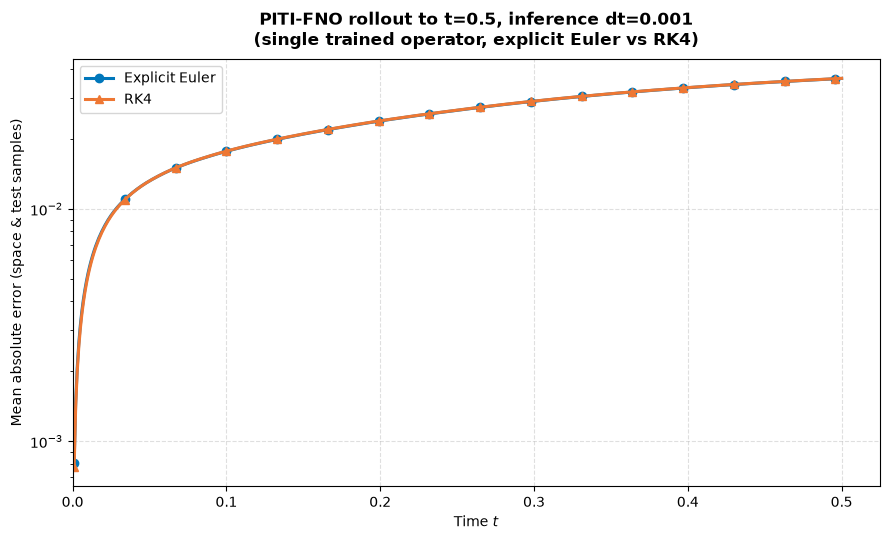

dt=0.001 final-step MAE: {'euler': '3.645e-02', 'rk4': '3.649e-02'}


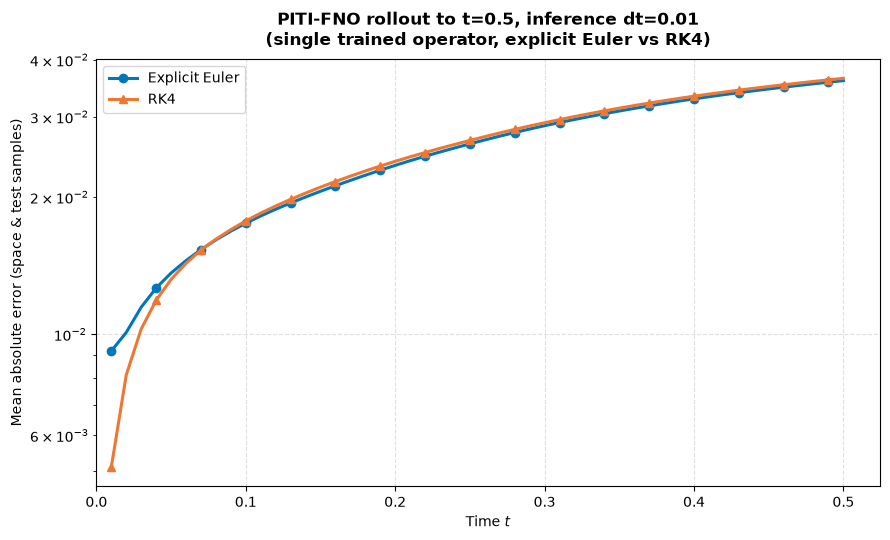

dt=0.01 final-step MAE: {'euler': '3.601e-02', 'rk4': '3.643e-02'}


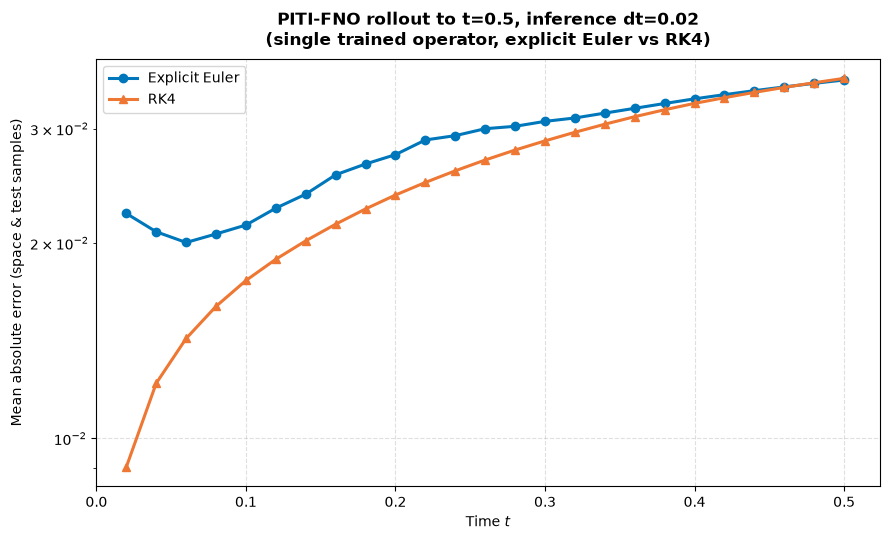

dt=0.02 final-step MAE: {'euler': '3.566e-02', 'rk4': '3.587e-02'}


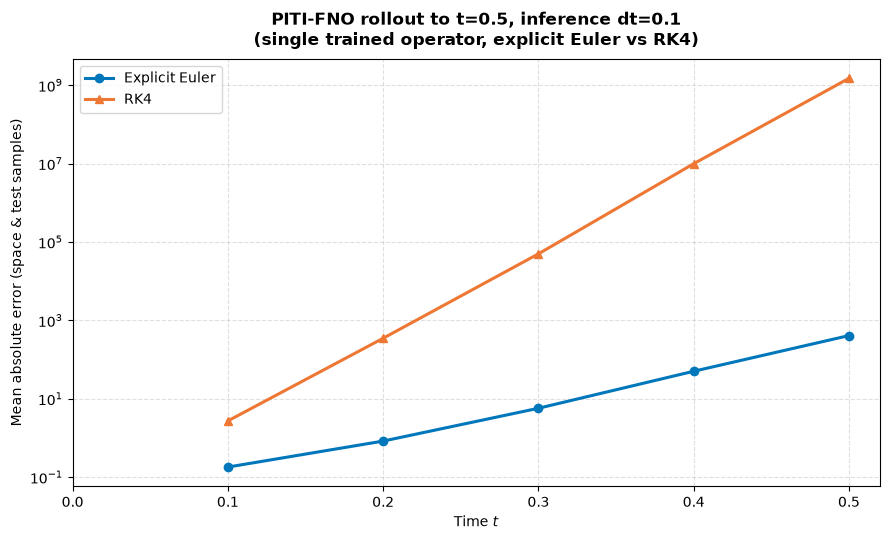

dt=0.1 final-step MAE: {'euler': '4.075e+02', 'rk4': '1.489e+09'}


In [9]:
# --- dt-decoupling sweep: same horizon (t=FINAL_TIME), 4 different inference dt's ---
rollout_errors_short = {}
for dt in INFER_DT_GRID:
    n_steps = HORIZON_STEPS_AT[dt]
    true_traj = fem_ground_truth(dt, n_steps, T0_test, A_test)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for name in INTEGRATORS:
        pred = rollout_fns[name](piti_params, T0_test, A_test, dt, n_steps)
        err = np.asarray(jnp.mean(jnp.abs(true_traj - pred), axis=(0, 2)))
        rollout_errors_short[(dt, name)] = err
        t_axis = dt * np.arange(n_steps + 1)
        # Skip t=0: the rollout starts FROM T0 so the error there is identically zero,
        # and log(0) = -inf renders as a vertical drop that also flattens the y-range.
        # Index 0 is still in `err` if you want to confirm it.
        ax.plot(t_axis[1:], err[1:], color=INTEG_COLORS[name], marker=INTEG_MARKERS[name],
                 markevery=max(1, n_steps // 15), lw=2.2, label=INTEG_LABELS[name])
    ax.set_xlabel("Time $t$"); ax.set_ylabel("Mean absolute error (space & test samples)")
    ax.set_title(f"PITI-FNO rollout to t={FINAL_TIME}, inference dt={dt}\n(single trained operator, explicit Euler vs RK4)",
                 fontweight="bold", pad=10)
    ax.set_yscale("log"); ax.grid(True, ls="--", alpha=0.4); ax.legend()
    ax.set_xlim(left=0.0)   # axis from t=0; the t=0 point itself is unplottable on log
    plt.tight_layout(); plt.savefig(f"piti_dt_decoupling_{dt}.png", dpi=150, bbox_inches="tight"); plt.show()
    print(f"dt={dt} final-step MAE:", {name: f"{rollout_errors_short[(dt, name)][-1]:.3e}" for name in INTEGRATORS})


### 7.2 Matched comparison with the weighted-residual operator

At the one time step where both exist, $\Delta t=0.02$, PITI is compared with the [weighted-residual operator](FNO_transient_weighted_residual.ipynb). Both are trained on the same $T_0$-only pool, use the same backbone and the same held-out samples, and are graded against the same reference. The two differ only in *where* the residual is evaluated: fully discrete (backward Euler inside the loss) for WR, semi-discrete (tangent only) for PITI. The dotted curve is the discretization floor: the error of an exact FEM solve on the same coarse grid (see [The Benchmark Problem](benchmark_problem.ipynb), Section 7). The second figure compares training and rollout cost.

saved compare_piti.npz | {'euler': '3.2811e-02', 'rk4': '3.2090e-02'}


inference [euler]: 132.24 ms for 100 samples x 19 steps (69.6 us per step per sample) | JIT compile 0.00s


inference [rk4]: 518.94 ms for 100 samples x 19 steps (273.1 us per step per sample) | JIT compile 0.00s
WR final-step mean MAE  1.5751e-02   |   PITI euler 3.2811e-02


discretization floor: step 1 = 5.39e-03, step 19 = 2.06e-03


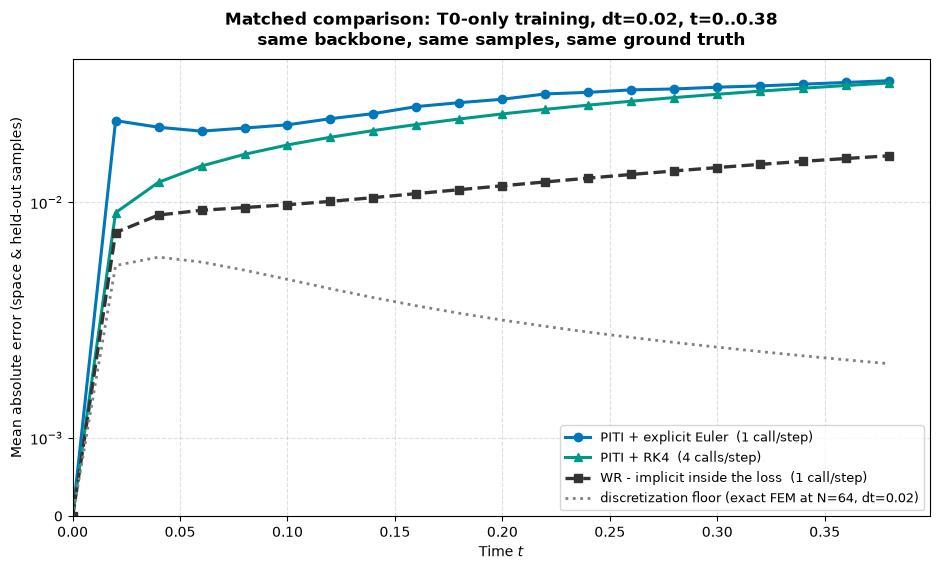


model                             train (s)  calls/step  rollout (ms)   us/step/sample
----------------------------------------------------------------------------------------------
WR                                    218.7           1        135.24             71.2
PITI+Explicit Euler                   131.6           1        132.24             69.6
PITI+RK4                              131.6           4        518.94            273.1
(rollout = 100 held-out samples x 19 steps at dt=0.02; JIT compilation excluded, reported separately above)


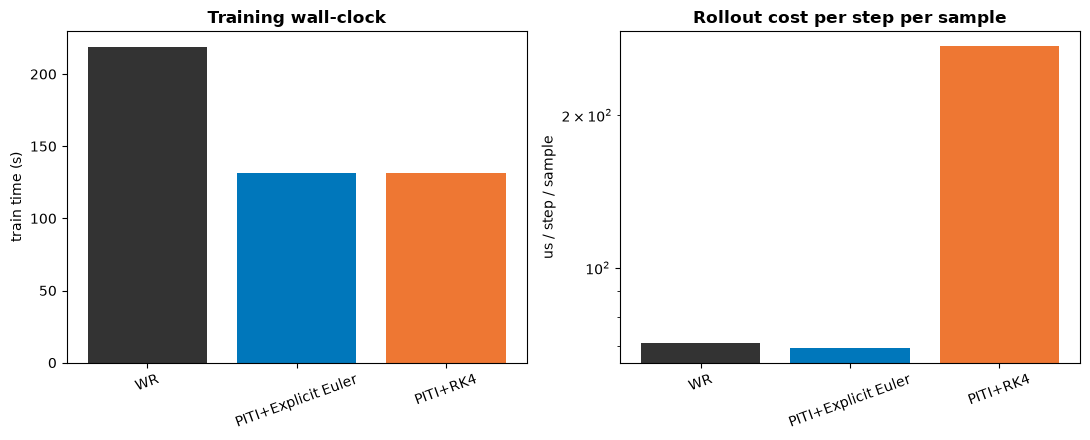

In [10]:
# ============================================================
# FAIR HEAD-TO-HEAD: PITI vs. the weighted-residual (WR) chapter
#
# Matched by construction:
#   - training pool   : T0 only, the same 1000 (T0, alpha) from the same reference (Section 4)
#   - test samples    : the same held-out 100 (ROLLOUT_TEST_START: of the same reference)
#   - ground truth    : the same derived FEM trajectory
#   - network         : same backbone, WIDTH = 64, MODES = 4, same sin(pi x) mask
#   - horizon         : t = 0..0.38, dt = 0.02  (the WR chapter's MAX_STEPS = 20)
#   - metric          : MEAN over samples and space, per step
#   - epoch budget    : MAX_EPOCHS = 20000, same optimizer and LR schedule
#
# NOT matched, deliberately -- this is the result, not a flaw:
#   - Explicit Euler  : 1 network call/step. Same update rule as WR's fno_model
#                       (T + dt*G(T)), so this pairing isolates WHERE the residual
#                       is evaluated -- fully-discrete backward-Euler (WR) vs.
#                       semi-discrete tangent (PITI).
#
# Asymmetry that cannot be removed: WR is locked to dt = 0.02 (baked into
# fno_model) and must be retrained for any other dt. These PITI weights run at
# any dt. At dt = 0.02 the comparison is fair; elsewhere WR cannot enter.
# ============================================================
import os

CMP_DT = 0.02
CMP_STEPS = 19          # == WR's MAX_STEPS - 1, so both reach t = 0.38
CMP_INTEGRATORS = ["euler", "rk4"]
CALLS_PER_STEP = {"euler": 1, "rk4": 4}

true_cmp = fem_ground_truth(CMP_DT, CMP_STEPS, T0_test, A_test)

cmp_curves = {}
for name in CMP_INTEGRATORS:
    pred = rollout_fns[name](piti_params, T0_test, A_test, CMP_DT, CMP_STEPS)
    # MEAN over held-out samples and space -- the same statistic the WR chapter
    # exports (its box plots draw the median, which is not comparable).
    cmp_curves[name] = np.asarray(jnp.mean(jnp.abs(true_cmp - pred), axis=(0, 2)))

np.savez(os.path.join(_CKPT_DIR, "compare_piti.npz"),
         dt=CMP_DT, n_steps=CMP_STEPS, modes=MODES,
         train_time_s=piti_train_time, n_test=T0_test.shape[0],
         **{f"mae_{n}": cmp_curves[n] for n in CMP_INTEGRATORS},
         **{f"calls_{n}": CALLS_PER_STEP[n] for n in CMP_INTEGRATORS})
print("saved compare_piti.npz |",
      {n: f"{cmp_curves[n][-1]:.4e}" for n in CMP_INTEGRATORS})


# ------------------------------------------------------------------
# Timing helper. JAX dispatches asynchronously and compiles on first
# call, so a naive perf_counter around a jitted function measures
# dispatch + compilation, not compute. This blocks on the result and
# reports the first (compile-inclusive) call separately from the
# steady-state cost.
# ------------------------------------------------------------------
def time_jax(fn, reps=5):
    t0 = time.perf_counter()
    out = fn(); jax.block_until_ready(out)
    t_first = time.perf_counter() - t0          # includes JIT compilation
    t0 = time.perf_counter()
    for _ in range(reps):
        out = fn(); jax.block_until_ready(out)
    t_steady = (time.perf_counter() - t0) / reps
    return t_steady, max(0.0, t_first - t_steady)

cmp_infer = {}
for name in CMP_INTEGRATORS:
    cmp_infer[name] = time_jax(
        lambda n=name: rollout_fns[n](piti_params, T0_test, A_test, CMP_DT, CMP_STEPS))
    _s, _c = cmp_infer[name]
    print(f"inference [{name}]: {1000*_s:.2f} ms for {T0_test.shape[0]} samples x {CMP_STEPS} steps "
          f"({1e6*_s/(T0_test.shape[0]*CMP_STEPS):.1f} us per step per sample) | JIT compile {_c:.2f}s")

# --- overlay with the WR curve, if that chapter has been run ---
WR_PATH = os.path.join(_CKPT_DIR, "compare_wr.npz")
t_axis = CMP_DT * np.arange(CMP_STEPS + 1)

SHOW_T0 = True          # False -> plain log axis, curves start at the first step
PLOT0 = 0 if SHOW_T0 else 1
fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.plot(t_axis[PLOT0:], cmp_curves["euler"][PLOT0:], color="#0077BB", marker="o", lw=2.2,
        label="PITI + explicit Euler  (1 call/step)")
ax.plot(t_axis[PLOT0:], cmp_curves["rk4"][PLOT0:], color="#009988", marker="^", lw=2.2,
        label=f"PITI + RK4  ({CALLS_PER_STEP['rk4']} calls/step)")

if os.path.exists(WR_PATH):
    wr = np.load(WR_PATH)
    wr_mae = wr["mae_mean"][:CMP_STEPS + 1]
    if int(wr["modes"]) != MODES:
        print(f"WARNING: compare_wr.npz was produced with MODES={int(wr['modes'])}, "
              f"this notebook uses MODES={MODES} -- rerun the WR chapter to match.")
    ax.plot(t_axis[PLOT0:len(wr_mae)], wr_mae[PLOT0:], color="#333333", marker="s", lw=2.4, ls="--",
            label="WR - implicit inside the loss  (1 call/step)")
    print(f"WR final-step mean MAE  {wr_mae[-1]:.4e}   |   PITI euler {cmp_curves['euler'][-1]:.4e}")
else:
    print(f"NOTE: {WR_PATH} not found -- run the WR chapter first to overlay its curve.")

# Irreducible floor: a PERFECT operator reproducing the N=64, dt=0.02 solution still
# differs from the N=256/dt=0.001 reference it is graded against. Measured here per step
# by solving the same held-out samples directly with FEM at N=64, dt=0.02.
fem_coarse = batch_fem_rollout(T0_test, A_test, CMP_STEPS, CMP_DT, RHO_CP, NEWTON_ITERS)
floor_curve = np.asarray(jnp.mean(jnp.abs(fem_coarse - true_cmp), axis=(0, 2)))
ax.plot(t_axis[PLOT0:], floor_curve[PLOT0:], color="gray", ls=":", lw=2,
        label="discretization floor (exact FEM at N=64, dt=0.02)")
print(f"discretization floor: step 1 = {floor_curve[1]:.2e}, step {CMP_STEPS} = {floor_curve[-1]:.2e}")

ax.set_xlabel("Time $t$")
ax.set_ylabel("Mean absolute error (space & held-out samples)")
ax.set_title(f"Matched comparison: T0-only training, dt={CMP_DT}, t=0..{CMP_DT*CMP_STEPS:.2f}\n"
             "same backbone, same samples, same ground truth", fontweight="bold", pad=10)
if SHOW_T0:
    ax.set_yscale("symlog", linthresh=1e-3, linscale=0.3)   # linear below 1e-3 so exact 0 is drawable
    ax.set_ylim(bottom=0)
else:
    ax.set_yscale("log")
ax.set_xlim(left=0.0)
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("wr_vs_piti_matched.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# RUNTIME COMPARISON. Two separate kernels/processes -- treat ratios as
# indicative, not a controlled benchmark.
# ============================================================
_n = T0_test.shape[0]
rows = []
if os.path.exists(WR_PATH):
    _w = np.load(WR_PATH)
    if "train_time_s" in _w.files and "infer_s" in _w.files:
        rows.append(("WR", float(_w["train_time_s"]), int(_w["calls_per_step"]),
                     float(_w["infer_s"]), int(_w["n_test"]), int(_w["n_steps"]) - 1))
    else:
        print("NOTE: compare_wr.npz predates the timing instrumentation -- rerun the WR "
              "notebook to include it in the runtime table. Accuracy curves above are unaffected.")
for name in CMP_INTEGRATORS:
    rows.append((f"PITI+{INTEG_LABELS[name]}", piti_train_time, CALLS_PER_STEP[name],
                 cmp_infer[name][0], _n, CMP_STEPS))

print()
print("=" * 94)
print(f"{'model':32s}{'train (s)':>11s}{'calls/step':>12s}{'rollout (ms)':>14s}{'us/step/sample':>17s}")
print("-" * 94)
for label, tr, calls, inf, nt, ns in rows:
    print(f"{label:32s}{tr:11.1f}{calls:12d}{1000*inf:14.2f}{1e6*inf/(nt*ns):17.1f}")
print("=" * 94)
print(f"(rollout = {_n} held-out samples x {CMP_STEPS} steps at dt={CMP_DT}; "
      "JIT compilation excluded, reported separately above)")

# --- runtime comparison, plotted ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = [r[0] for r in rows]
train_times = [r[1] for r in rows]
us_per_step = [1e6 * r[3] / (r[4] * r[5]) for r in rows]
bar_colors = ["#333333"] + [INTEG_COLORS[n] for n in CMP_INTEGRATORS]

axes[0].bar(labels, train_times, color=bar_colors[:len(labels)])
axes[0].set_ylabel("train time (s)")
axes[0].set_title("Training wall-clock", fontweight="bold")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, us_per_step, color=bar_colors[:len(labels)])
axes[1].set_ylabel("us / step / sample")
axes[1].set_yscale("log")
axes[1].set_title("Rollout cost per step per sample", fontweight="bold")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("wr_vs_piti_runtime.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Discussion: stiffness and explicit integration

- The loss does not depend on $\Delta t$, so errors are only meaningfully comparable *within* a plot, across integrators/$\Delta t$'s for this one operator.
- Training uses a single loss term, $\mathcal L_{PDE}$, defined directly on the residual at the current state, with no separate target computed or compared against. One theoretical risk: the mass matrix $M$ nearly cancels alternating-sign, node-to-node tangent errors that an unweighted comparison would catch.
- The network has one output head, the tangent $\tilde T^n_t$; there is no online, ground-truth-free proxy for prediction quality during a rollout.

### Why explicit Euler's early-step error looks the way it does

Linearizing $\dot T = -M^{-1}K\,T$ at a state $T_0$ gives the generalized eigenproblem
$$K\,v_i = \lambda_i\,M\,v_i$$
whose eigenmodes $v_i$ each decay independently in the true physics, $c_i(t) = c_i(0)\,e^{-\lambda_i t}$.

Explicit Euler updates each mode's coefficient by an amplification factor per step:
$$c_i^{n+1} = (1-\Delta t\,\lambda_i)\,c_i^{n}, \qquad r_i := 1-\Delta t\,\lambda_i$$
stable ($|r_i|\le 1$) only for
$$\Delta t < \frac{2}{\lambda_i}$$

Heat conduction is stiff: on this mesh (N=64) $\lambda$ ranges from ~0.4 (smoothest mode) to ~5000+ (the most jagged, node-to-node mode), so a single global $\Delta t$ fine for the slow modes can be catastrophically unstable for the fast ones -- the constraint that matters is set by the largest $\lambda$ present, $\Delta t < 2/\lambda_{\max}$.

Two control experiments (same FEM matrices, run standalone) confirmed this is a property of the physics, not an implementation error:
- Feeding the exact FEM tangent (no network) through explicit Euler at $\Delta t=0.02$ diverges to NaN by step 2 -- matching the ~2.6e-2 first-step error scale seen when comparing against WR.
- The trained PITI operator stays stable for $\Delta t \le 0.02$ with both integrators, because `MODES=4` caps its output to the four smoothest, slowest-decaying modes ($\lambda \lesssim 8$) -- it structurally cannot represent the stiff, fast-decaying content that makes the exact tangent blow up at $\Delta t=0.02$. The cost of that safety is accuracy: the network's own error still grows with rollout length. The truncation is not a blanket guarantee, though: at $\Delta t=0.1$ (Section 7) both integrators diverge -- the learned operator's own Jacobian still has eigenvalues large enough that $\Delta t\,\hat\lambda$ leaves both methods' stability regions, and RK4, despite its larger real-axis stability interval, grows faster here than Euler.

The elevated first-step error for explicit Euler in the matched comparison is the expected signature of a stiff problem stepped with a conditionally-stable integrator, at a step size close to the stability boundary for the modes the network can represent -- not a defect in the loss, the architecture, or the rollout code.


## 9. MODES ablation: explicit-Euler stability vs. spectral truncation

The FNO's spectral layer keeps only the first `modes` Fourier coefficients of its hidden representation and zeros the rest before the inverse transform:
$$\hat x_k \leftarrow \hat x_k \quad (k < \text{modes}), \qquad \hat x_k \leftarrow 0 \quad (k \ge \text{modes})$$

This caps the highest spatial frequency, and therefore the largest eigenvalue $\lambda$ (of the linearized operator $M^{-1}K$), the network's output can contain. Writing $\lambda_{\max}(\text{modes})$ for that cap, explicit Euler's stability condition becomes
$$\Delta t < \frac{2}{\lambda_{\max}(\text{modes})}$$
Since $\lambda$ grows with mode number (roughly quadratically for this diffusion operator), $\lambda_{\max}(\text{modes})$ increases with `modes` -- so this condition predicts that explicit Euler at a fixed $\Delta t$ should stay stable for small `modes` and become unstable once `modes` is large enough to push $\lambda_{\max}(\text{modes})$ past $2/\Delta t$.

Four single-output PITI-FNO operators were trained from scratch, identical in every respect (architecture, $T_i$-only pool, weighted-residual loss, epoch budget) except `MODES` $\in \{2, 4, 8, 16\}$. Each was then rolled out with explicit Euler only, at $\Delta t=0.02$, against the same held-out FEM ground truth used throughout this chapter.


In [11]:
# ============================================================
# MODES ablation. Reuses train_states/val_states/T0_test/A_test/GRID/FREE/
# assemble_mk/fem_ground_truth from Sections 4-7 above; only the FNO's
# spectral truncation (MODES) varies between the four trained operators
# below. Model builders are re-parameterized on `modes` (closures named
# _modes to avoid clobbering the Section 5 globals fno_tdot/init_params,
# which stay at MODES=4 for the rest of the notebook).
# ============================================================
MODES_LIST = [2, 4, 8, 16]

def make_model_modes(modes):
    def spectral_layer(x, w_spec, w_skip):
        n = x.shape[0]; xf = jnp.fft.rfft(x, axis=0)
        of = jnp.zeros_like(xf, dtype=jnp.complex64).at[:modes].set(jnp.einsum('mi,mij->mj', xf[:modes], w_spec))
        return jax.nn.gelu(jnp.fft.irfft(of, n=n, axis=0) + jnp.dot(x, w_skip))

    def fno_tdot_m(params, x_norm):
        x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
        for i in range(2, 10, 2):
            x = spectral_layer(x, params[i], params[i + 1])
        x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
        T_dot = (jnp.dot(x, params[12]) + params[13]).squeeze()
        mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, x_norm.shape[0]))
        return T_dot * mask

    def init_params_m(key):
        keys = jax.random.split(key, 12)
        def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
        p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
        for i in range(4):
            p.append(jax.random.normal(keys[i + 1], (modes, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
            p.append(norm_init(keys[i + 5], (WIDTH, WIDTH)))
        p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH),
                  norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
        return p
    return fno_tdot_m, init_params_m

def train_one_modes(modes, seed=101):
    fno_tdot_m, init_params_m = make_model_modes(modes)

    def piti_losses_m(params, T_curr, alpha):
        T_dot_pred = fno_tdot_m(params, normalize_input(T_curr, alpha, GRID))
        M, K = assemble_mk(T_curr, alpha)
        pde_res = (M @ T_dot_pred + K @ T_curr)[FREE]
        pde_scale = (K @ T_curr)[FREE]
        denom = jnp.sum(pde_scale ** 2) + REL_EPS
        L_pde = jnp.sum(T_dot_pred[FREE] * jax.lax.stop_gradient(pde_res)) / denom
        pde_quality = jnp.sum(pde_res ** 2) / denom
        return L_pde, (L_pde, pde_quality)

    @jax.jit
    def batch_loss_m(params, T_batch, A_batch):
        total, parts = jax.vmap(piti_losses_m, (None, 0, 0))(params, T_batch, A_batch)
        return jnp.mean(total), tuple(jnp.mean(p) for p in parts)

    @jax.jit
    def val_metric_m(params, T_batch, A_batch):
        _, parts = batch_loss_m(params, T_batch, A_batch)
        return parts[1]

    sched = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=MAX_EPOCHS, alpha=1e-2)
    opt = optax.adamw(learning_rate=sched, weight_decay=1e-4)
    params = init_params_m(jax.random.PRNGKey(seed))
    opt_state = opt.init(params)

    @jax.jit
    def step_m(p, opt_s, T_b, A_b):
        (loss, parts), g = jax.value_and_grad(lambda pp: batch_loss_m(pp, T_b, A_b), has_aux=True)(p)
        u, opt_s = opt.update(g, opt_s, p)
        return optax.apply_updates(p, u), opt_s, loss, parts

    best_val, best_params, best_epoch, stall = jnp.inf, params, 0, 0
    for i in range(MAX_EPOCHS):
        idx = jax.random.randint(jax.random.PRNGKey(seed * 1_000_003 + i), (BATCH_SIZE,), 0, train_states.shape[0])
        params, opt_state, loss, parts = step_m(params, opt_state, train_states[idx], train_alphas[idx])
        if i % CHECK_EVERY == 0:
            v = float(val_metric_m(params, val_states, val_alphas))
            if v < best_val:
                best_val, best_params, best_epoch, stall = v, params, i, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    break
    return best_params, fno_tdot_m, best_val, best_epoch

def rollout_explicit_euler_modes(fno_tdot_m, params, T0b, ab, dt, n_steps):
    def single(T0, a):
        def body(T, _):
            Tn = T + dt * fno_tdot_m(params, normalize_input(T, a, GRID))
            return Tn, Tn
        _, traj = jax.lax.scan(body, T0, None, length=n_steps)
        return jnp.concatenate([T0[None, :], traj], axis=0)
    return jax.jit(jax.vmap(single, (0, 0)))(T0b, ab)

modes_ablation_results = {}
for modes in MODES_LIST:
    t0 = time.perf_counter()
    params_m, fno_tdot_m, best_val_m, best_epoch_m = train_one_modes(modes)
    jax.block_until_ready(params_m)
    train_time_m = time.perf_counter() - t0
    pred_m = rollout_explicit_euler_modes(fno_tdot_m, params_m, T0_test, A_test, CMP_DT, CMP_STEPS)
    mae_m = np.asarray(jnp.mean(jnp.abs(true_cmp - pred_m), axis=(0, 2)))
    modes_ablation_results[modes] = mae_m
    print(f"MODES={modes:3d} | train {train_time_m:6.1f}s | best_val {best_val_m:.3e} @ epoch {best_epoch_m:5d} "
          f"| explicit-Euler MAE  step1={mae_m[1]:.3e}  step{CMP_STEPS}={mae_m[-1]:.3e}"
          + ("  <-- diverged" if not np.isfinite(mae_m[-1]) else ""))


MODES=  2 | train   90.4s | best_val 1.342e-01 @ epoch  9000 | explicit-Euler MAE  step1=2.217e-02  step19=4.222e-02


MODES=  4 | train  122.3s | best_val 1.166e-01 @ epoch 12000 | explicit-Euler MAE  step1=2.221e-02  step19=3.281e-02


MODES=  8 | train   99.5s | best_val 1.835e-01 @ epoch  7800 | explicit-Euler MAE  step1=2.478e-02  step19=1.105e-01


MODES= 16 | train  154.5s | best_val 2.410e-01 @ epoch 11200 | explicit-Euler MAE  step1=2.382e-02  step19=8.984e+21


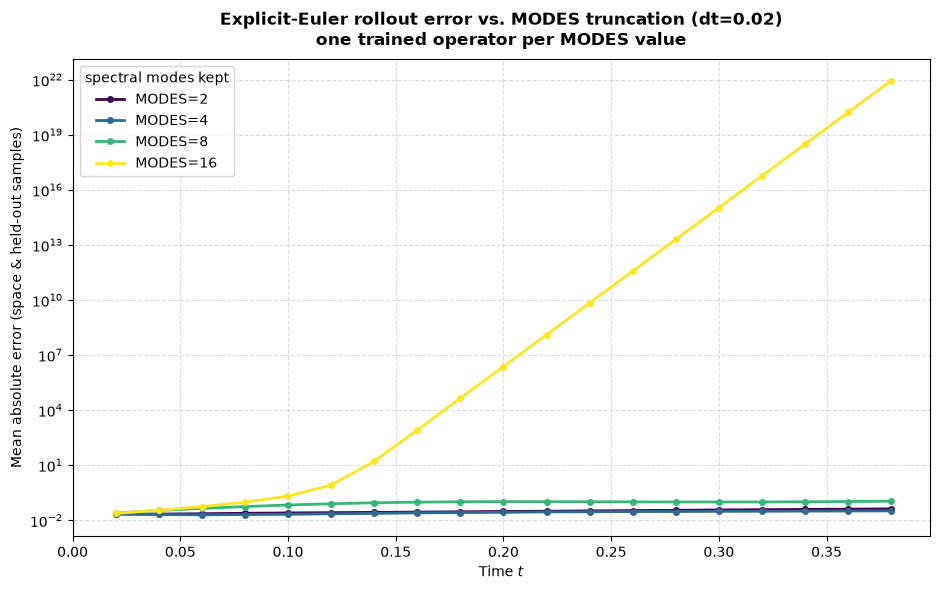

In [12]:
# --- all MODES curves on one figure, explicit Euler, dt=CMP_DT ---
fig, ax = plt.subplots(figsize=(9.5, 6))
t_axis_m = CMP_DT * np.arange(CMP_STEPS + 1)
cmap = plt.get_cmap('viridis')
for i, modes in enumerate(MODES_LIST):
    mae_m = modes_ablation_results[modes]
    color = cmap(i / max(1, len(MODES_LIST) - 1))
    finite = np.isfinite(mae_m)
    ax.plot(t_axis_m[1:][finite[1:]], mae_m[1:][finite[1:]], marker='o', ms=4, lw=2, color=color, label=f"MODES={modes}")
ax.set_xlabel("Time $t$"); ax.set_ylabel("Mean absolute error (space & held-out samples)")
ax.set_title(f"Explicit-Euler rollout error vs. MODES truncation (dt={CMP_DT})\none trained operator per MODES value", fontweight='bold', pad=10)
ax.set_yscale("log"); ax.grid(True, ls="--", alpha=0.4); ax.legend(title="spectral modes kept")
ax.set_xlim(left=0.0)
plt.tight_layout()
plt.savefig("modes_ablation_explicit_euler.png", dpi=150, bbox_inches="tight")
plt.show()


### Results

| MODES | step-1 MAE | step-19 MAE ($t=0.38$) | best val (pde_quality) | best epoch |
|---|---|---|---|---|
| 2 | 0.0222 | 0.0422 (stable) | 0.134 | 9000 |
| 4 | 0.0222 | 0.0328 (stable) | 0.117 | 12000 |
| 8 | 0.0248 | 0.110 (stable, elevated) | 0.184 | 7800 |
| 16 | 0.0238 | $9\times10^{21}$ (diverged) | 0.241 | 11200 |

MODES=16 diverges exponentially from $t\approx0.1$, as the truncation argument predicts: with 16 modes the network can represent content whose $\lambda$ exceeds $2/\Delta t=100$. MODES=2, 4 and 8 all stay finite. MODES=4 has the lowest rollout error *and* the lowest validation residual, which is why it is the setting used throughout this chapter. MODES=8 does not diverge but settles on a plateau roughly three times higher than MODES=4 -- consistent with its extra, weakly-constrained spectral weights (the training $T_0$ carry 99.5% of their perturbation energy in modes 1-3) injecting error the explicit step then carries forward.

The middle of this picture is **not robust to training variance**. A repeated run of the same ablation (identical setup, different JAX version) found MODES=2 diverging (step-19 MAE 72.4) and MODES=8 stable (0.040), with MODES=4 stable (0.029) and MODES=16 diverged in both runs. So the only conclusions that survive both runs are the endpoints: MODES=4 is stable and accurate, and MODES=16 is unstable. Whether MODES=2 or 8 destabilizes depends on where a particular training run lands.

A clean version of this ablation would (a) average multiple random seeds per MODES value and report the spread, and (b) measure the trained operator's own local Jacobian eigenvalues directly ($\partial \mathcal G_\theta/\partial T$ via `jax.jacfwd`, then $\Delta t\cdot\hat\lambda_{\max}$ against the stability threshold) rather than inferring $\lambda_{\max}(\text{modes})$ only indirectly through rollout divergence.


## 10. Conclusions

- **Time step decoupled from training.** PITI's loss contains no $\Delta t$. One set of weights is rolled out at $\Delta t = 0.001$, $0.01$ and $0.02$ with explicit Euler or RK4, all stable and with similar accuracy.
- **Stability limits remain.** At $\Delta t = 0.1$ both explicit integrators diverge. Learning the tangent does not remove the stiffness of heat conduction, it only moves the stability question from training to inference (Section 8).
- **Accuracy cost.** At $\Delta t = 0.02$, PITI's rollout error is about twice that of the weighted-residual operator, which builds the implicit step into its loss. RK4 removes explicit Euler's first-step jump but not the long-horizon gap.
- **Spectral truncation matters.** With `MODES=4` the operator is stable and most accurate. Too many modes (16) admit stiff content and diverge; the behaviour of 2 and 8 modes is sensitive to the training run (Section 9).

The [transient comparison](transient_comparison.ipynb) puts all three transient operators side by side, in and out of distribution.